# Initial Data Processing

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [42]:
df_404 = pd.read_csv("404.7.csv")
df_435 = pd.read_csv("435.8.csv")
df_577 = pd.read_csv("577.0.csv")

# Plateau Variation

In [43]:
def plateau_var(df, plateau_cutoff, V_unc = 0.01/np.sqrt(12)):
    I_cols = ["I_1","I_2","I_3","I_4","I_5"]

    V = df["V"].values
    I_mat = df[I_cols].values

    I_mean = np.nanmean(I_mat, axis=1)
    I_std  = np.nanstd(I_mat, axis=1, ddof=1)

    plateau_mask = V >= plateau_cutoff
    I_plateau = I_mat[plateau_mask, :]

    # --- plateau stats ---
    mu_p = np.nanmean(I_plateau)
    sd_p = np.nanstd(I_plateau, ddof=1)

    # effective N (all individual plateau measurements)
    N = np.sum(~np.isnan(I_plateau))

    # uncertainties of plateau stats
    mu_p_unc = sd_p / np.sqrt(N)
    sd_p_unc = sd_p / np.sqrt(2*(N-1))

    # --- thresholds ---
    I_th_nom = mu_p + 1.5*sd_p
    I_th_hi  = (mu_p + mu_p_unc) + 1.5*(sd_p + sd_p_unc)
    I_th_lo  = (mu_p - mu_p_unc) + 1.5*(sd_p - sd_p_unc)

    def find_Vstop(I_th):
        below = I_mean <= I_th
        k = 2
        for i in range(len(V) - k + 1):
            if below[i] and np.all(below[i:i+k]):
                return V[i]
        return None

    V_nom = find_Vstop(I_th_nom)
    V_hi  = find_Vstop(I_th_hi)
    V_lo  = find_Vstop(I_th_lo)

    V_stop = (V_hi + V_lo)/2
    V_stop_unc = abs(V_hi - V_lo)/2

    V_stop_unc = np.sqrt(V_stop_unc**2 + V_unc**2)

    # --- plotting ---
    plt.figure(figsize=(6,4))

    xerr = np.full_like(V, V_unc, dtype=float)  # constant V uncertainty on each point

    plt.errorbar(
        V, I_mean,
        xerr=xerr,          # <-- voltage uncertainty shown here
        yerr=I_std,
        fmt='o', capsize=2,
        label="Mean ± SD (across trials)"
    )

    plt.axhline(I_th_nom, linestyle='--', label="Nominal threshold")
    plt.axhline(I_th_hi, linestyle=':', color='gray', alpha=0.6)
    plt.axhline(I_th_lo, linestyle=':', color='gray', alpha=0.6)

    if V_stop is not None:
        plt.axvline(V_stop, linestyle='--',
                    label=rf"$V_s = {V_stop:.3f} \pm {V_stop_unc:.3f}$ V")
        plt.axvspan(V_stop - V_stop_unc, V_stop + V_stop_unc, alpha=0.15)  # <-- band

    plt.xlabel("Voltage V (V)")
    plt.ylabel("Photocurrent I (pA)")
    plt.title("Stopping Voltage via Plateau Threshold (with uncertainty)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return V_stop, V_stop_unc

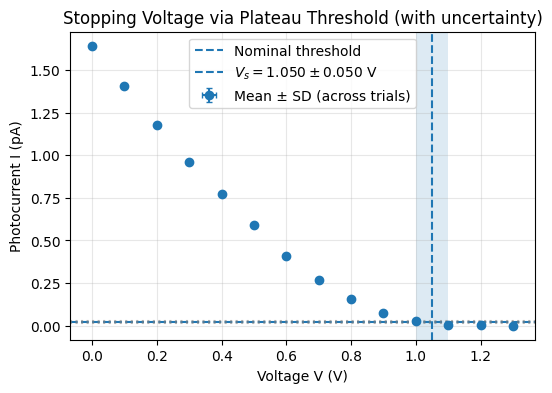

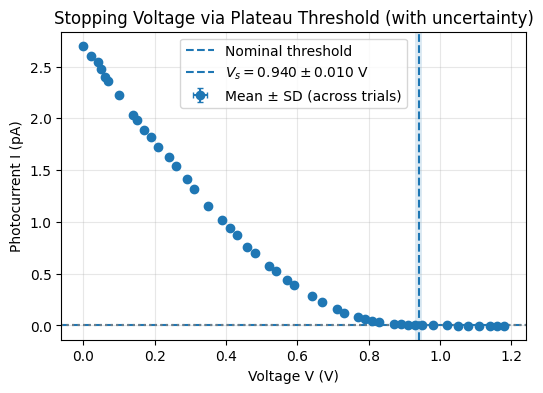

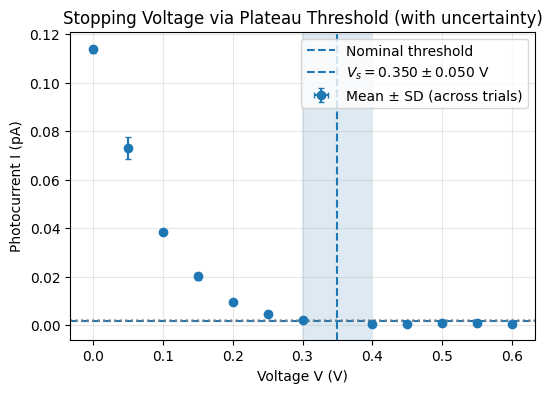

In [44]:
V_404, sV_404 = plateau_var(df_404, 1.0)
V_435, sV_435 = plateau_var(df_435, 0.9)
V_577, sV_577 = plateau_var(df_577, 0.3)

## 404.7nm

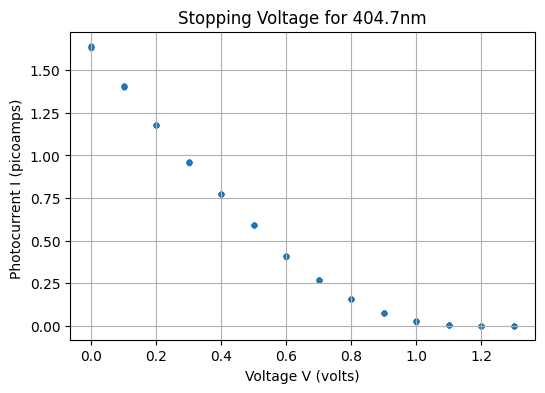

In [45]:
V_all = np.repeat(df_404["V"].values, 5)
I_all = df_404[["I_1","I_2","I_3","I_4","I_5"]].values.flatten()

plt.figure(figsize=(6,4))
plt.scatter(V_all, I_all, s=10)
plt.xlabel("Voltage V (volts)")
plt.ylabel("Photocurrent I (picoamps) ")
plt.title("Stopping Voltage for 404.7nm")
plt.grid(True)
plt.show()

In [46]:
I_cols = ["I_1","I_2","I_3","I_4","I_5"]

V = df_404["V"].values
I_mat = df_404[I_cols].values          # shape (nV, 5)

I_mean = np.nanmean(I_mat, axis=1)     # mean across trials at each V
I_std  = np.nanstd(I_mat, axis=1, ddof=1)

In [47]:
plateau_mask = V >= 1.0   # example; tweak for your data
mu_p = np.nanmean(I_mean[plateau_mask])
sd_p = np.nanstd(I_mean[plateau_mask], ddof=1)

I_th = mu_p + 2*sd_p
print("plateau mean:", mu_p, "plateau sd:", sd_p, "threshold:", I_th)

plateau mean: 0.0073799999999999985 plateau sd: 0.01155364185008346 threshold: 0.030487283700166918


In [48]:
# indices where mean current is below threshold
below = I_mean <= I_th

# enforce "stays below" by requiring k consecutive points below threshold
k = 3
V_stop_404 = None
for i in range(len(V) - k + 1):
    if below[i] and np.all(below[i:i+k]):
        V_stop_404 = V[i]
        break

print("V_stop (threshold method) =", V_stop_404)

V_stop (threshold method) = 1.0


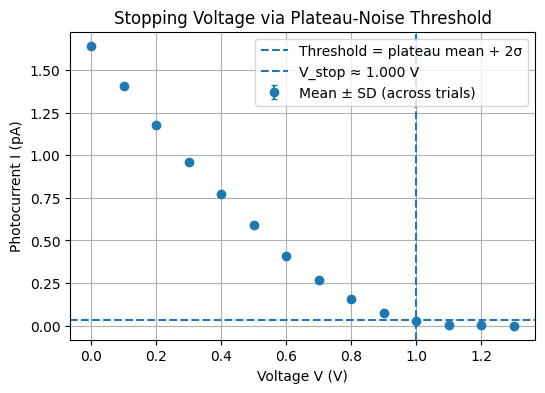

In [49]:
plt.figure(figsize=(6,4))
plt.errorbar(V, I_mean, yerr=I_std, fmt='o', capsize=2, label="Mean ± SD (across trials)")

plt.axhline(I_th, linestyle='--', label="Threshold = plateau mean + 2σ")
if V_stop_404 is not None:
    plt.axvline(V_stop_404, linestyle='--', label=f"V_stop ≈ {V_stop_404:.3f} V")

plt.xlabel("Voltage V (V)")
plt.ylabel("Photocurrent I (pA)")
plt.title("Stopping Voltage via Plateau-Noise Threshold")
plt.grid(True)
plt.legend()
plt.show()

## 435nm

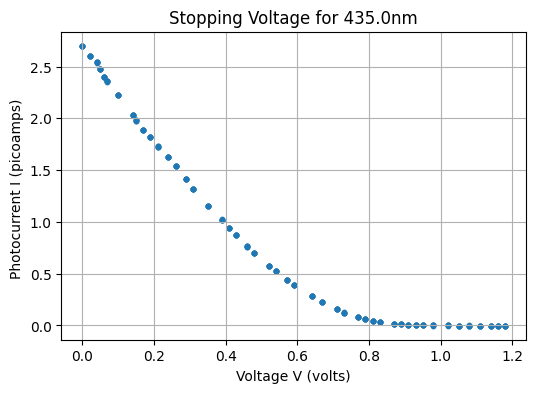

In [50]:
V_all = np.repeat(df_435["V"].values, 5)
I_all = df_435[["I_1","I_2","I_3","I_4","I_5"]].values.flatten()

plt.figure(figsize=(6,4))
plt.scatter(V_all, I_all, s=10)
plt.xlabel("Voltage V (volts)")
plt.ylabel("Photocurrent I (picoamps) ")
plt.title("Stopping Voltage for 435.0nm")
plt.grid(True)
plt.show()

In [51]:
I_cols = ["I_1","I_2","I_3","I_4","I_5"]

V = df_435["V"].values
I_mat = df_435[I_cols].values          # shape (nV, 5)

I_mean = np.nanmean(I_mat, axis=1)     # mean across trials at each V
I_std  = np.nanstd(I_mat, axis=1, ddof=1)

In [52]:
plateau_mask = V >= 0.8  # example; tweak for your data
mu_p = np.nanmean(I_mean[plateau_mask])
sd_p = np.nanstd(I_mean[plateau_mask], ddof=1)

I_th = mu_p + 2*sd_p
print("plateau mean:", mu_p, "plateau sd:", sd_p, "threshold:", I_th)

plateau mean: 0.007918266666666667 plateau sd: 0.014968265838417082 threshold: 0.037854798343500834


In [53]:
# indices where mean current is below threshold
below = I_mean <= I_th

# enforce "stays below" by requiring k consecutive points below threshold
k = 3
V_stop_435 = None
for i in range(len(V) - k + 1):
    if below[i] and np.all(below[i:i+k]):
        V_stop_435 = V[i]
        break

print("V_stop (threshold method) =", V_stop_435)

V_stop (threshold method) = 0.83


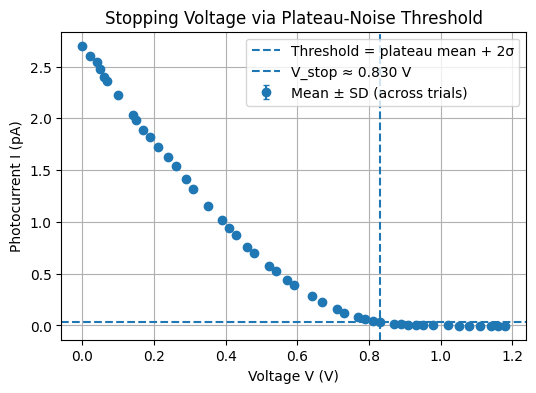

In [54]:
plt.figure(figsize=(6,4))
plt.errorbar(V, I_mean, yerr=I_std, fmt='o', capsize=2, label="Mean ± SD (across trials)")

plt.axhline(I_th, linestyle='--', label="Threshold = plateau mean + 2σ")
if V_stop_435 is not None:
    plt.axvline(V_stop_435, linestyle='--', label=f"V_stop ≈ {V_stop_435:.3f} V")

plt.xlabel("Voltage V (V)")
plt.ylabel("Photocurrent I (pA)")
plt.title("Stopping Voltage via Plateau-Noise Threshold")
plt.grid(True)
plt.legend()
plt.show()

## 577.0nm

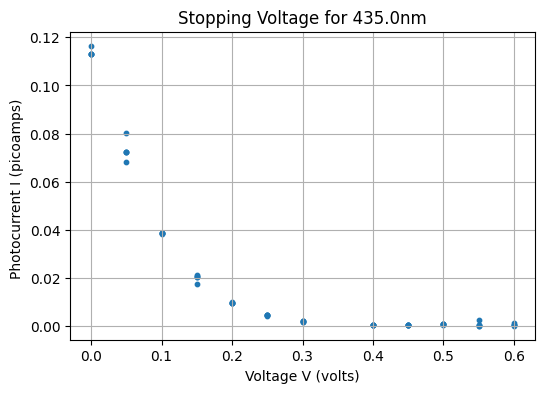

In [55]:
V_all = np.repeat(df_577["V"].values, 5)
I_all = df_577[["I_1","I_2","I_3","I_4","I_5"]].values.flatten()

plt.figure(figsize=(6,4))
plt.scatter(V_all, I_all, s=10)
plt.xlabel("Voltage V (volts)")
plt.ylabel("Photocurrent I (picoamps) ")
plt.title("Stopping Voltage for 435.0nm")
plt.grid(True)
plt.show()

In [56]:
I_cols = ["I_1","I_2","I_3","I_4","I_5"]

V = df_577["V"].values
I_mat = df_577[I_cols].values          # shape (nV, 5)

I_mean = np.nanmean(I_mat, axis=1)     # mean across trials at each V
I_std  = np.nanstd(I_mat, axis=1, ddof=1)

In [57]:
plateau_mask = V >= 0.3  # example; tweak for your data
mu_p = np.nanmean(I_mean[plateau_mask])
sd_p = np.nanstd(I_mean[plateau_mask], ddof=1)

I_th = mu_p + 2*sd_p
print("plateau mean:", mu_p, "plateau sd:", sd_p, "threshold:", I_th)

plateau mean: 0.0008453333333333335 plateau sd: 0.0005675754281737952 threshold: 0.001980484189680924


In [58]:
# indices where mean current is below threshold
below = I_mean <= I_th

# enforce "stays below" by requiring k consecutive points below threshold
k = 3
V_stop_577 = None
for i in range(len(V) - k + 1):
    if below[i] and np.all(below[i:i+k]):
        V_stop_577 = V[i]
        break

print("V_stop (threshold method) =", V_stop_577)

V_stop (threshold method) = 0.3


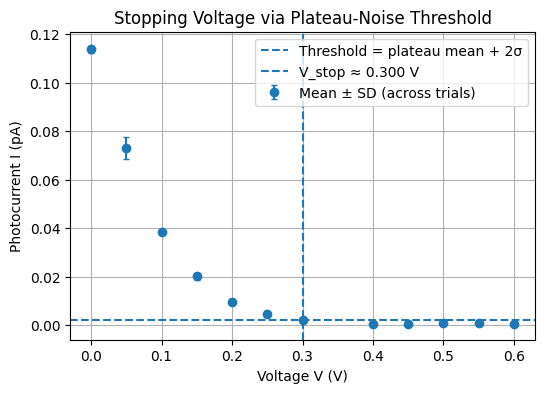

In [59]:
plt.figure(figsize=(6,4))
plt.errorbar(V, I_mean, yerr=I_std, fmt='o', capsize=2, label="Mean ± SD (across trials)")

plt.axhline(I_th, linestyle='--', label="Threshold = plateau mean + 2σ")
if V_stop_577 is not None:
    plt.axvline(V_stop_577, linestyle='--', label=f"V_stop ≈ {V_stop_577:.3f} V")

plt.xlabel("Voltage V (V)")
plt.ylabel("Photocurrent I (pA)")
plt.title("Stopping Voltage via Plateau-Noise Threshold")
plt.grid(True)
plt.legend()
plt.show()

In [60]:
# # TEST
# V_stop_577 = 0.2

# Estimating h

In [61]:
V_stops      = np.array([V_404, V_435, V_577])
# V_stops      = np.array([V_435, V_577])
V_stops_unc  = np.array([sV_404, sV_435, sV_577])
# V_stops_unc  = np.array([sV_435, sV_577])

In [62]:
# wavelengths in nm (example — replace with yours)
wavelengths = np.array([404.7, 435.8, 577.0])
# wavelengths = np.array([435.8, 577.0])

# wavelengths in nm (example — replace with yours)
wave_unc = 2  # Uncertainty in wavelength measurement (nm)

c = 299792458  # speed of light (m/s)

# convert nm -> m, then compute frequency
frequencies = c / (wavelengths * 1e-9)
freq_unc = (c / (wavelengths * 1e-9)**2) * wave_unc * 1e-9  # propagate uncertainty

In [63]:
from scipy.odr import ODR, Model, RealData

def linear_odr(beta, x):
    return beta[0] * x + beta[1]

data = RealData(frequencies, np.array(V_stops), sx=freq_unc, sy=np.array(V_stops_unc))
odr_result = ODR(data, Model(linear_odr), beta0=[1e-15, -1.0]).run()

m, b = odr_result.beta
m_err = odr_result.sd_beta[0]

h_over_e = m
print("h/e =", h_over_e)

h/e = 3.3613849739775255e-15


In [64]:
e = 1.602e-19
h_est = e * h_over_e

print("Estimated h =", h_est, "J·s")
print("Error: ", m_err * e, "J·s")

Estimated h = 5.384938728311996e-34 J·s
Error:  6.112605049504132e-35 J·s


In [65]:
from scipy.stats import t
dof = len(frequencies) - 2
t95 = t.ppf(0.975, dof)
sigma_h = m_err * e
print("h =", h_est, "+/-", sigma_h, "(1σ)")
print("h =", h_est, "+/-", t95*sigma_h, "(95% CI)")

h = 5.384938728311996e-34 +/- 6.112605049504132e-35 (1σ)
h = 5.384938728311996e-34 +/- 7.766801123037477e-34 (95% CI)


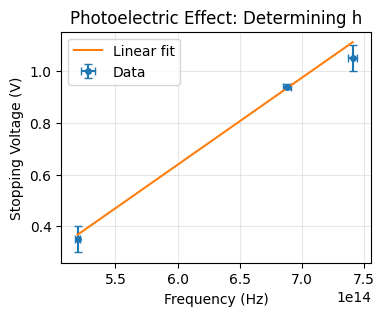

In [66]:
plt.figure(figsize=(4,3))
plt.errorbar(frequencies, V_stops, yerr=V_stops_unc, xerr=freq_unc, fmt='o', markersize=4.0, capsize=3.0, label="Data")

# best fit line
f_fit = np.linspace(min(frequencies), max(frequencies), 200)
# plt.plot(f_fit, m*f_fit + b, label=rf"Linear fit: $h = ({h_est/1e-34:.2f} \pm {m_err*e/1e-34:.2f}) \times 10^{{-34}}$ J·s")
plt.plot(f_fit, m*f_fit + b, label=rf"Linear fit")


plt.xlabel("Frequency (Hz)")
plt.ylabel("Stopping Voltage (V)")
plt.title("Photoelectric Effect: Determining h")
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

## Ignore below

In [67]:
# wavelengths in nm (example — replace with yours)
wavelengths_nm = np.array([404.7, 435.8, 577.0])

# stopping voltages (replace with your values)
V_stop = np.array([V_stop_404, V_stop_435, V_stop_577])

c = 2.99792458e8  # speed of light (m/s)

# convert nm -> m, then compute frequency
frequencies = c / (wavelengths_nm * 1e-9)

In [68]:
m, b = np.polyfit(frequencies, V_stop, 1)

h_over_e = m
print("h/e =", h_over_e)

h/e = 3.160557507049365e-15


In [69]:
e = 1.602e-19
h_est = e * h_over_e

print("Estimated h =", h_est, "J·s")

Estimated h = 5.063213126293083e-34 J·s


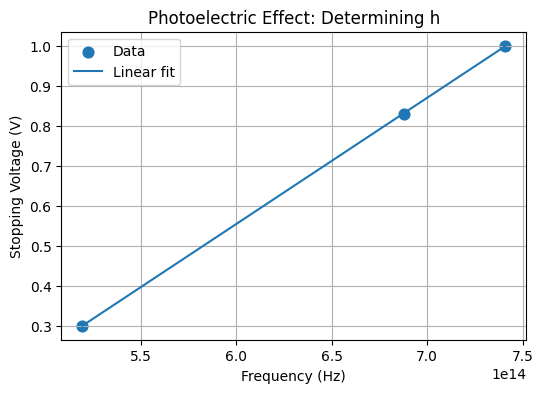

In [70]:
plt.figure(figsize=(6,4))
plt.scatter(frequencies, V_stop, s=60, label="Data")

# best fit line
f_fit = np.linspace(min(frequencies), max(frequencies), 200)
plt.plot(f_fit, m*f_fit + b, label="Linear fit")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Stopping Voltage (V)")
plt.title("Photoelectric Effect: Determining h")
plt.legend()
plt.grid(True)
plt.show()

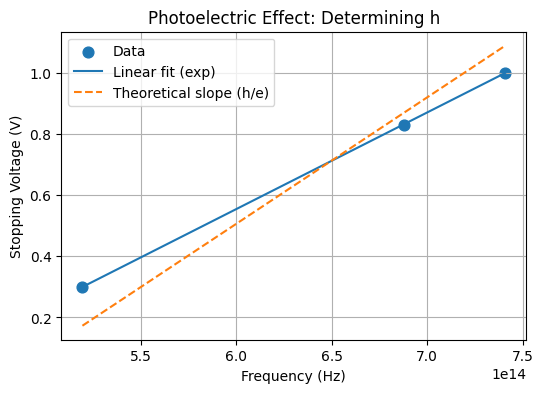

In [71]:
plt.figure(figsize=(6,4))
plt.scatter(frequencies, V_stop, s=60, label="Data")

# best fit line (your experiment)
f_fit = np.linspace(min(frequencies), max(frequencies), 200)
plt.plot(f_fit, m*f_fit + b, label="Linear fit (exp)")

# theoretical slope line
h_true = 6.62607015e-34
e = 1.602e-19
true_slope = h_true / e
b_true = np.mean(V_stop) - true_slope * np.mean(frequencies)
plt.plot(f_fit, true_slope*f_fit + b_true, '--', label="Theoretical slope (h/e)")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Stopping Voltage (V)")
plt.title("Photoelectric Effect: Determining h")
plt.legend()
plt.grid(True)
plt.show()